<a href="https://colab.research.google.com/github/detoma2158208-bit/progetto-intelligenza-artificiale-/blob/main/progetto_finale_IAII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESCRIZIONE DEL DATASET

##import

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline

##caricamento file csv

In [113]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
dataset_path= "/content/drive/MyDrive/"
df= pd.read_csv(dataset_path  + 'data.csv', index_col=None,header=0)
df.head()

,gender,C_api,C_man,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,...,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,male,1,2,2,20170527205915,20170721044501,543,56,43,...,4,0,0,91,28,6,76,324,0.915024,978
1,0,unknown,3,3,1,20110301072441,20170731213735,2764,2345,514,...,7,0,0,100,249,183,646,1526,0.661673,477
2,1,male,1,0,2,20060907204302,20140911191722,57,2927,25,...,0,0,0,3,0,1,3,49,0.800528,664
3,1,male,1,1,2,20121003144916,20121208180528,104,67,5,...,2,0,0,20,1,2,2,78,1.027717,841
4,0,unknown,3,1,1,20070311125035,20141106121057,184,2798,27,...,0,0,0,26,10,5,24,112,0.997535,994


## analisi della struttura del dataset

In [115]:
print ("osservazioni totali nel CSV: ", df.shape [0])
print ("osservazioni totali nel CVS: ", df.shape [1])

osservazioni totali nel CSV:  4746
osservazioni totali nel CVS:  21


In [116]:
df.dtypes

,0
gender,int64
C_api,object
C_man,int64
E_NEds,int64
E_Bpag,int64
firstDay,int64
lastDay,int64
NEds,int64
NDays,int64
NActDays,int64


In [117]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   gender         4746 non-null   int64  
 1   C_api          4746 non-null   object 
 2   C_man          4746 non-null   int64  
 3   E_NEds         4746 non-null   int64  
 4   E_Bpag         4746 non-null   int64  
 5   firstDay       4746 non-null   int64  
 6   lastDay        4746 non-null   int64  
 7   NEds           4746 non-null   int64  
 8   NDays          4746 non-null   int64  
 9   NActDays       4746 non-null   int64  
 10  NPages         4746 non-null   int64  
 11  NPcreated      4746 non-null   int64  
 12  pagesWomen     4746 non-null   int64  
 13  wikiprojWomen  4746 non-null   int64  
 14  ns_user        4746 non-null   int64  
 15  ns_wikipedia   4746 non-null   int64  
 16  ns_talk        4746 non-null   int64  
 17  ns_userTalk    4746 non-null   int64  
 18  ns_conte

In [118]:
df.isnull().sum()

,0
gender,0
C_api,0
C_man,0
E_NEds,0
E_Bpag,0
firstDay,0
lastDay,0
NEds,0
NDays,0
NActDays,0


## analisi iniziale della colonna target

In [119]:
df['gender'].value_counts ()
(df["gender"].value_counts(normalize=True)*100).round(2)

,proportion
gender,
1,58.83
0,33.73
2,7.44


In [120]:
df.describe()

,gender,C_man,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,NPages,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
count,4746.000000,4746.000000,4746.000000,4746.000000,4.746000e+03,4.746000e+03,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000
mean,0.737042,2.082807,1.484197,1.646228,2.009942e+13,2.015489e+13,2029.969448,2036.607880,183.162663,689.451960,43.479140,0.438896,0.439949,74.372946,74.368310,49.947745,96.081753,1521.886641,1.000000,867.148546
std,0.585355,0.964978,1.099795,1.079263,3.516337e+10,1.748104e+10,7793.300833,1336.119914,374.034481,3355.302483,297.395507,5.327440,17.832244,246.407233,560.782479,215.554281,545.025818,6099.009235,0.325763,325.933076
min,0.000000,1.000000,0.000000,0.000000,2.002011e+13,2.012010e+13,50.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.411985,297.000000
25%,0.000000,1.000000,1.000000,1.000000,2.007042e+13,2.014070e+13,95.000000,835.250000,24.000000,29.000000,1.000000,0.000000,0.000000,4.000000,0.000000,0.000000,1.000000,61.000000,0.831954,664.000000
50%,1.000000,3.000000,1.000000,2.000000,2.009121e+13,2.016072e+13,218.000000,2035.500000,53.000000,68.000000,4.000000,0.000000,0.000000,14.000000,1.000000,4.000000,5.000000,151.000000,0.997535,917.000000
75%,1.000000,3.000000,2.000000,3.000000,2.013040e+13,2.017073e+13,757.750000,3146.500000,154.000000,219.750000,14.000000,0.000000,0.000000,46.000000,8.000000,19.000000,22.000000,563.750000,1.057149,994.000000
max,2.000000,3.000000,3.000000,3.000000,2.017093e+13,2.017100e+13,153193.000000,5349.000000,3843.000000,94142.000000,13394.000000,185.000000,949.000000,6041.000000,24392.000000,4788.000000,12350.000000,115547.000000,1.865008,1596.000000


#DATA CLEANING E PREPARAZIONE INIZIALE

##conversione feature con date

In [121]:
df['firstDay'] = pd.to_datetime(df['firstDay'].astype(str), format='%Y%m%d%H%M%S')
df.head()


,gender,C_api,C_man,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,...,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,male,1,2,2,2017-05-27 20:59:15,20170721044501,543,56,43,...,4,0,0,91,28,6,76,324,0.915024,978
1,0,unknown,3,3,1,2011-03-01 07:24:41,20170731213735,2764,2345,514,...,7,0,0,100,249,183,646,1526,0.661673,477
2,1,male,1,0,2,2006-09-07 20:43:02,20140911191722,57,2927,25,...,0,0,0,3,0,1,3,49,0.800528,664
3,1,male,1,1,2,2012-10-03 14:49:16,20121208180528,104,67,5,...,2,0,0,20,1,2,2,78,1.027717,841
4,0,unknown,3,1,1,2007-03-11 12:50:35,20141106121057,184,2798,27,...,0,0,0,26,10,5,24,112,0.997535,994


In [122]:
df['lastDay'] = pd.to_datetime(df['lastDay'].astype(str), format='%Y%m%d%H%M%S')
df.head()

,gender,C_api,C_man,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,...,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,male,1,2,2,2017-05-27 20:59:15,2017-07-21 04:45:01,543,56,43,...,4,0,0,91,28,6,76,324,0.915024,978
1,0,unknown,3,3,1,2011-03-01 07:24:41,2017-07-31 21:37:35,2764,2345,514,...,7,0,0,100,249,183,646,1526,0.661673,477
2,1,male,1,0,2,2006-09-07 20:43:02,2014-09-11 19:17:22,57,2927,25,...,0,0,0,3,0,1,3,49,0.800528,664
3,1,male,1,1,2,2012-10-03 14:49:16,2012-12-08 18:05:28,104,67,5,...,2,0,0,20,1,2,2,78,1.027717,841
4,0,unknown,3,1,1,2007-03-11 12:50:35,2014-11-06 12:10:57,184,2798,27,...,0,0,0,26,10,5,24,112,0.997535,994


In [123]:
df.dtypes

,0
gender,int64
C_api,object
C_man,int64
E_NEds,int64
E_Bpag,int64
firstDay,datetime64[ns]
lastDay,datetime64[ns]
NEds,int64
NDays,int64
NActDays,int64


##rimozione colonne inutili

In [124]:
df2 = df.drop(columns= ['C_api', 'C_man'])
df2.head ()

,gender,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,NPages,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,2,2,2017-05-27 20:59:15,2017-07-21 04:45:01,543,56,43,204,4,0,0,91,28,6,76,324,0.915024,978
1,0,3,1,2011-03-01 07:24:41,2017-07-31 21:37:35,2764,2345,514,722,7,0,0,100,249,183,646,1526,0.661673,477
2,1,0,2,2006-09-07 20:43:02,2014-09-11 19:17:22,57,2927,25,25,0,0,0,3,0,1,3,49,0.800528,664
3,1,1,2,2012-10-03 14:49:16,2012-12-08 18:05:28,104,67,5,66,2,0,0,20,1,2,2,78,1.027717,841
4,0,1,1,2007-03-11 12:50:35,2014-11-06 12:10:57,184,2798,27,125,0,0,0,26,10,5,24,112,0.997535,994


In [125]:
df2['gender'].value_counts ()
(df2["gender"].value_counts(normalize=True)*100).round(2)

,proportion
gender,
1,58.83
0,33.73
2,7.44


## analisi colonna target scelta

In [126]:
df['gender'].value_counts ()
(df["gender"].value_counts(normalize=True)*100).round(2)

,proportion
gender,
1,58.83
0,33.73
2,7.44


##creazione df2_known e separazione unkown

In [127]:
df2_known = df2[df2["gender"].isin([1, 2])].copy()
df2_known.head (100)

,gender,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,NPages,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,2,2,2017-05-27 20:59:15,2017-07-21 04:45:01,543,56,43,204,4,0,0,91,28,6,76,324,0.915024,978
2,1,0,2,2006-09-07 20:43:02,2014-09-11 19:17:22,57,2927,25,25,0,0,0,3,0,1,3,49,0.800528,664
3,1,1,2,2012-10-03 14:49:16,2012-12-08 18:05:28,104,67,5,66,2,0,0,20,1,2,2,78,1.027717,841
5,1,3,1,2006-05-26 14:19:42,2017-09-14 13:19:32,1887,4130,197,510,62,0,0,7,2,31,10,1660,0.661673,477
7,1,3,3,2008-11-05 22:48:14,2017-08-18 01:29:59,5833,3209,566,376,108,0,0,161,10,9,184,4744,1.481654,1596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,1,1,2,2011-04-05 14:10:56,2017-08-20 21:43:28,121,2330,37,57,1,0,0,30,6,8,2,57,1.027717,841
158,2,1,1,2016-10-20 07:55:33,2017-05-15 18:49:17,109,208,19,9,0,0,0,91,0,1,13,4,0.997535,994
159,2,0,0,2005-05-23 11:01:05,2012-05-27 18:22:51,88,2562,15,11,2,0,0,2,0,1,2,83,1.865008,1277
160,1,0,3,2017-02-04 14:14:33,2017-02-06 18:04:26,61,3,3,3,1,0,0,60,0,0,0,1,0.411985,297


In [128]:
df2_unknown = df2[df2["gender"] == 0]
df2_unknown.head ()

,gender,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,NPages,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
1,0,3,1,2011-03-01 07:24:41,2017-07-31 21:37:35,2764,2345,514,722,7,0,0,100,249,183,646,1526,0.661673,477
4,0,1,1,2007-03-11 12:50:35,2014-11-06 12:10:57,184,2798,27,125,0,0,0,26,10,5,24,112,0.997535,994
6,0,0,1,2013-07-22 23:41:49,2013-07-31 13:06:29,57,10,7,13,1,0,0,10,0,4,6,37,1.057149,1074
10,0,1,3,2011-05-10 15:53:59,2016-09-21 11:24:01,160,1962,40,42,0,0,0,36,0,34,28,60,0.594368,493
14,0,0,2,2010-10-13 09:16:09,2015-07-27 12:18:54,81,1749,38,34,0,0,0,33,0,0,0,30,0.800528,664


##controllo dimensioni e colonne df2_known

In [129]:
print("Osservazioni (righe):", df2_known.shape[0])
print("Colonne totali:", df2_known.shape[1])
print("Colonne:", df2_known.columns)

Osservazioni (righe): 3145
Colonne totali: 19
Colonne: Index(['gender', 'E_NEds', 'E_Bpag', 'firstDay', 'lastDay', 'NEds', 'NDays',
       'NActDays', 'NPages', 'NPcreated', 'pagesWomen', 'wikiprojWomen',
       'ns_user', 'ns_wikipedia', 'ns_talk', 'ns_userTalk', 'ns_content',
       'weightIJ', 'NIJ'],
      dtype='object')


##definizioni X e y iniziali

In [130]:
y = df2_known["gender"]
X = df2_known.drop(columns=["gender"])
y.head (100)

,gender
0,1
2,1
3,1
5,1
7,1
...,...
157,1
158,2
159,2
160,1


#EDA: analisi esplorativa dei dati

##distribuzione target

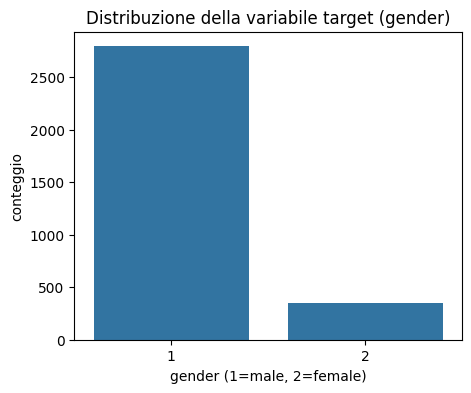

In [131]:
plt.figure(figsize=(5,4))
sns.countplot(x='gender', data=df2_known)
plt.title("Distribuzione della variabile target (gender)")
plt.xlabel("gender (1=male, 2=female)")
plt.ylabel("conteggio")
plt.show()

##distribuzione delle features

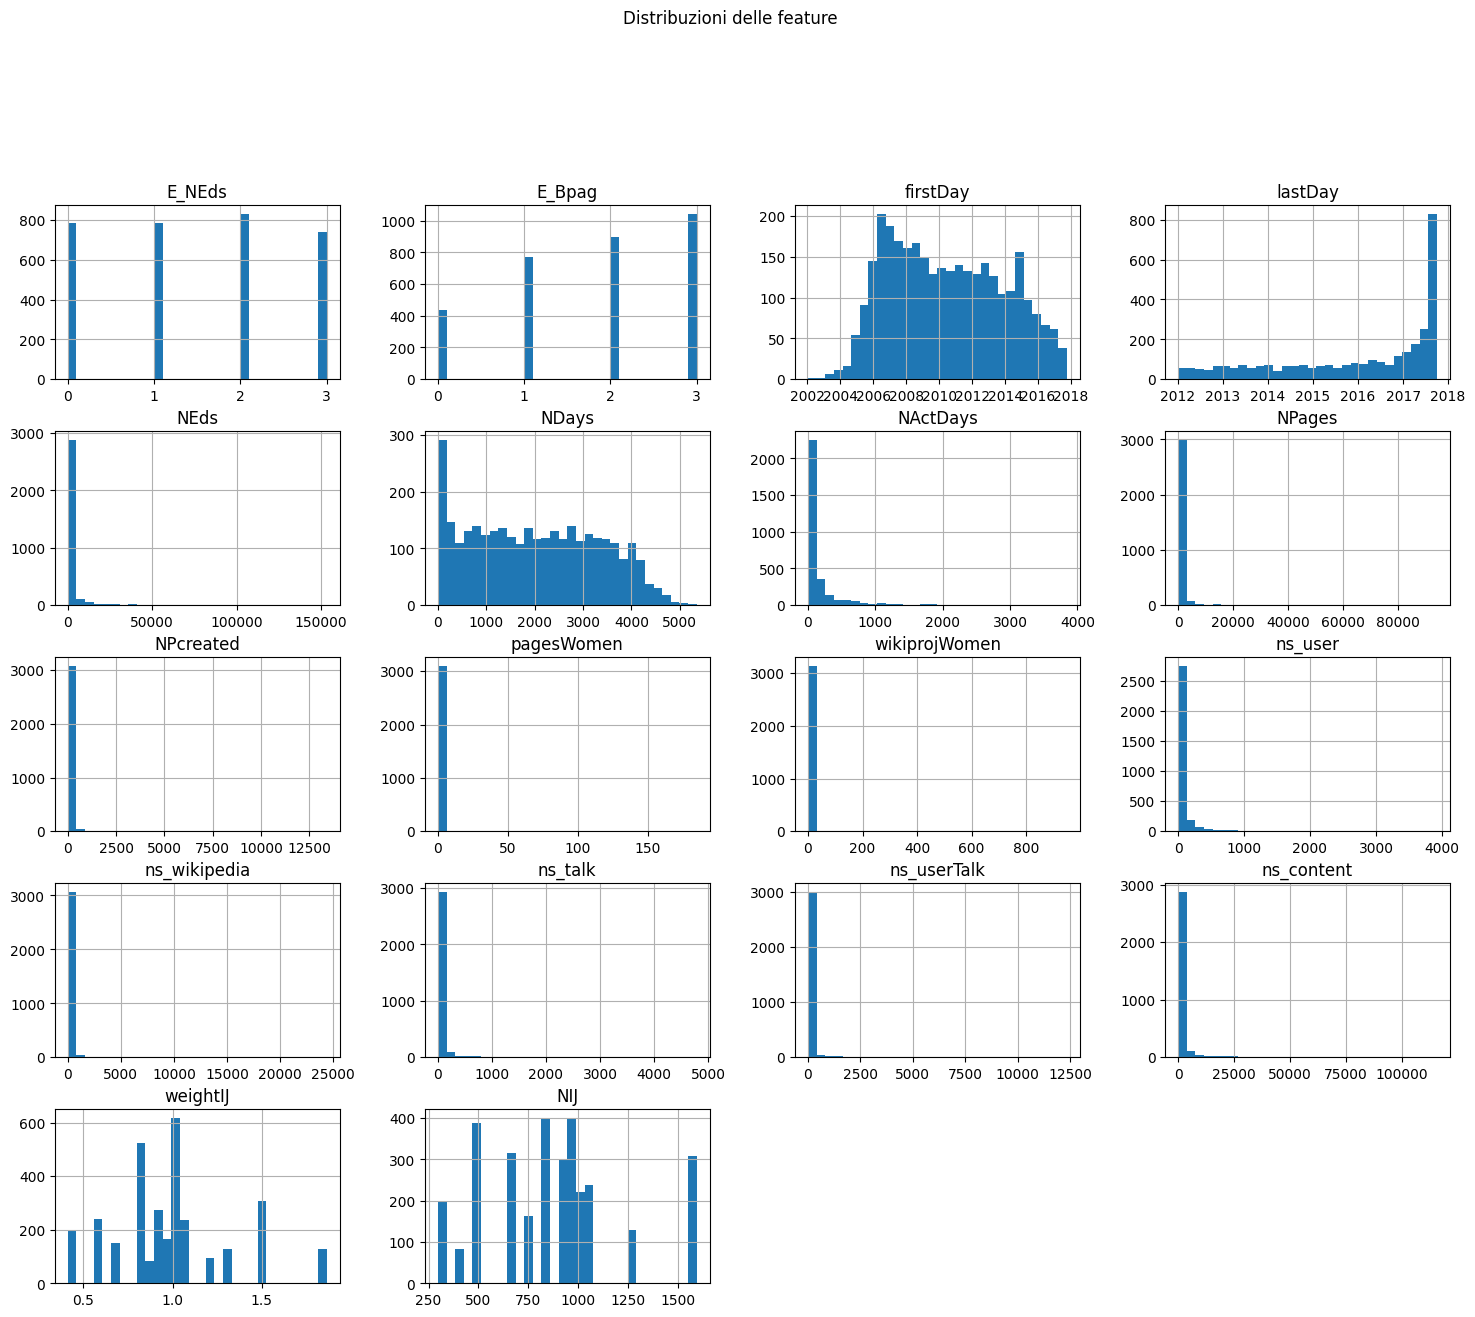

In [132]:
df2_known.drop(columns=['gender']).hist(figsize=(18,14), bins=30)
plt.suptitle("Distribuzioni delle feature", y=1.02)
plt.show()

##istogrammi e boxplot delle features

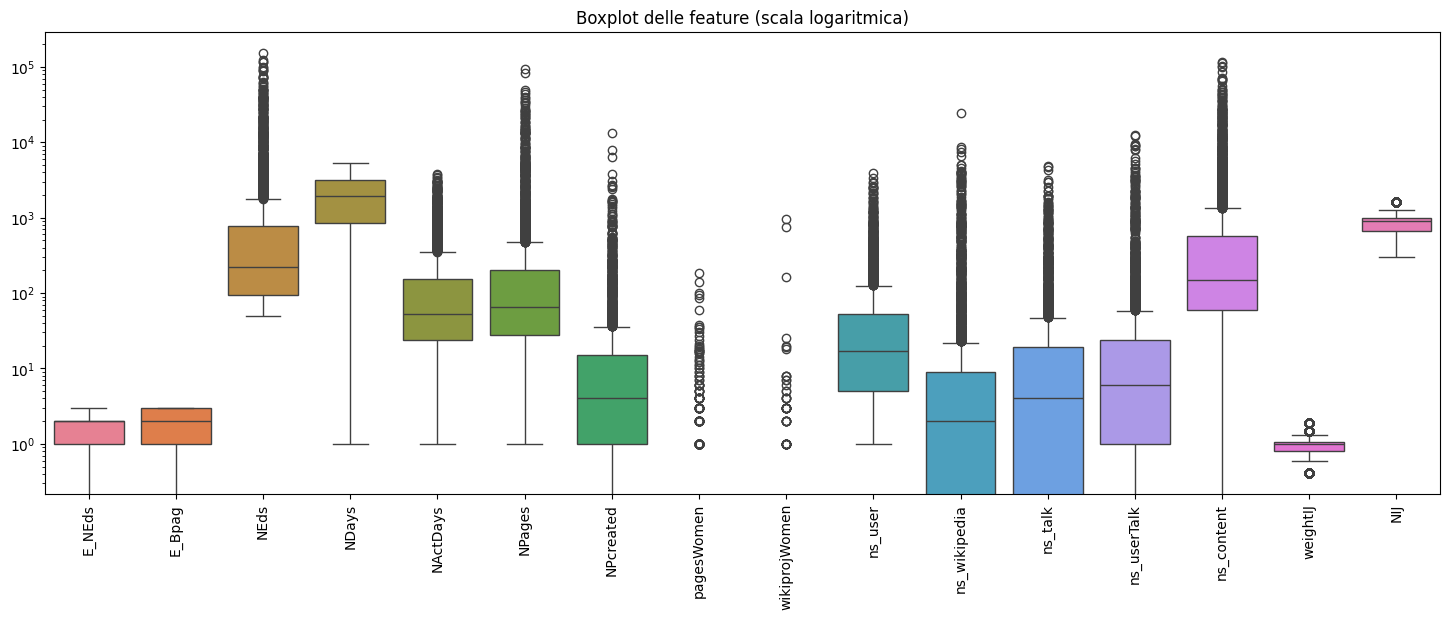

In [133]:
plt.figure(figsize=(18,6))
sns.boxplot(data=df2_known.drop(columns=['gender']))
plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Boxplot delle feature (scala logaritmica)")
plt.show()

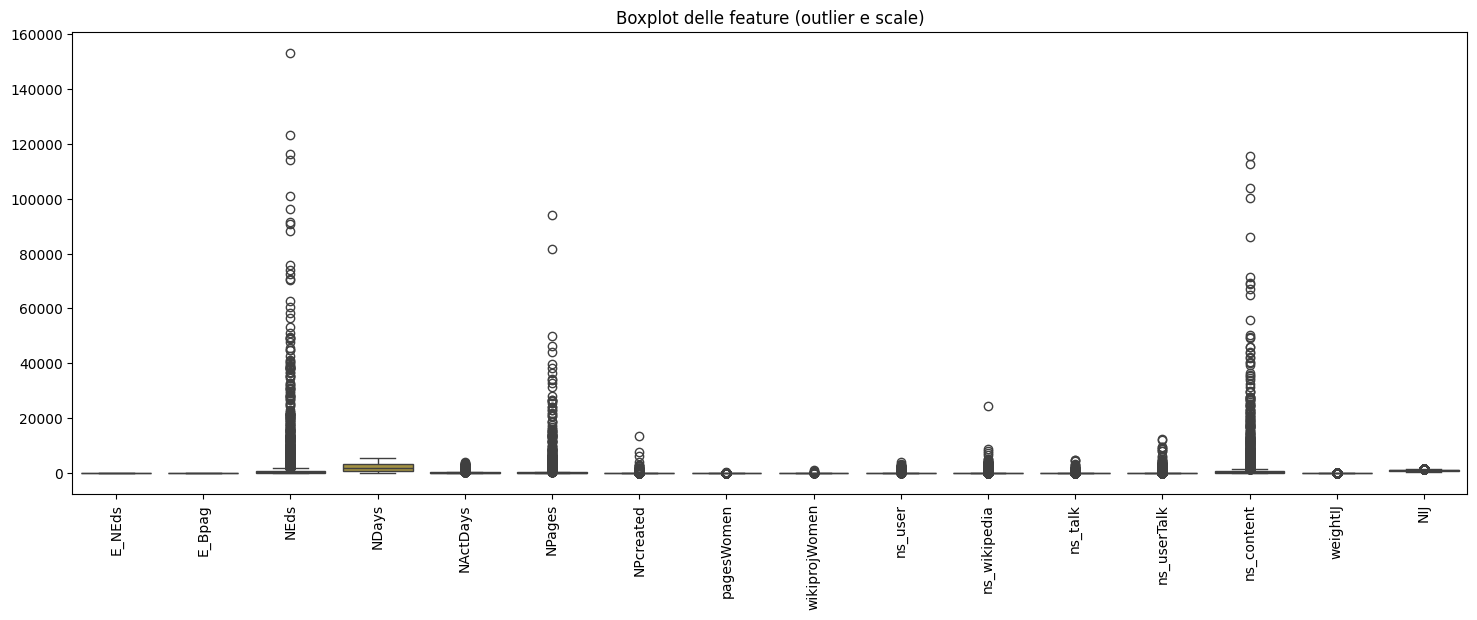

In [134]:
plt.figure(figsize=(18,6))
sns.boxplot(data=df2_known.drop(columns=['gender']))
plt.xticks(rotation=90)
plt.title("Boxplot delle feature (outlier e scale)")
plt.show()

##matrice di correlazioni generale

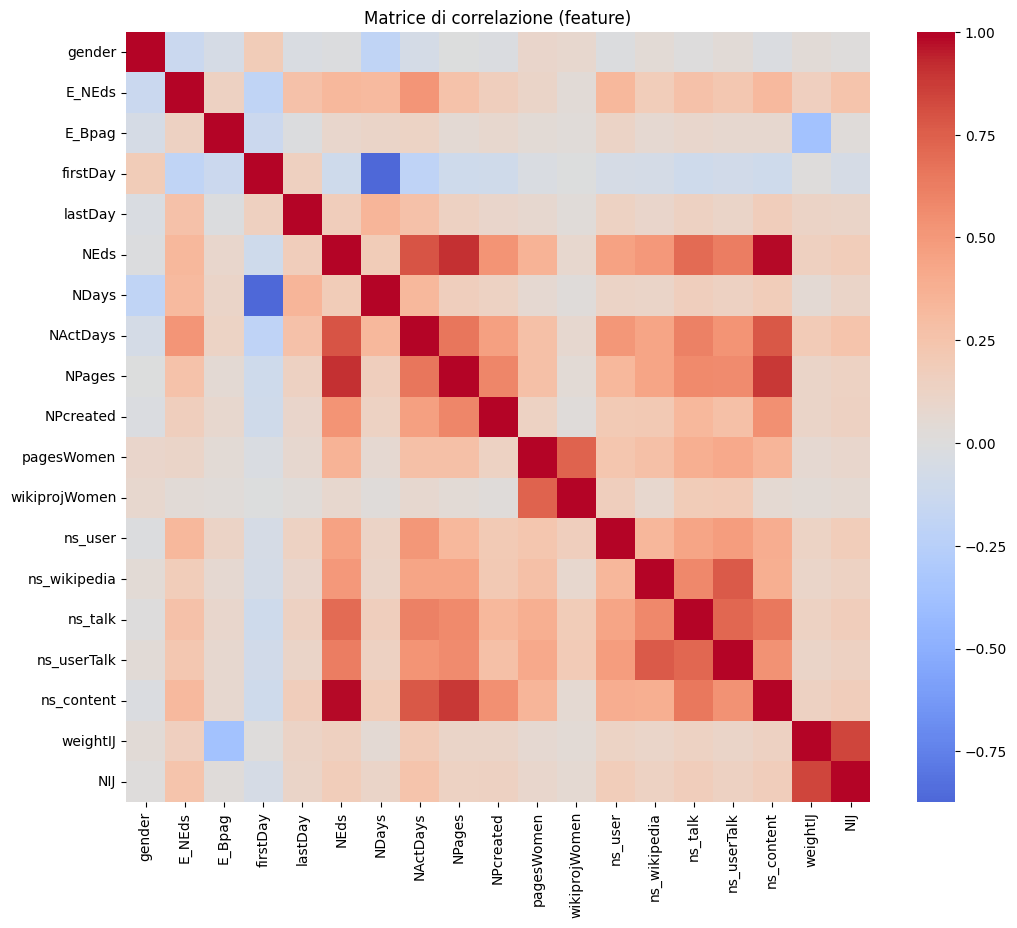

In [135]:
corr = df2_known.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione (feature)")
plt.show()

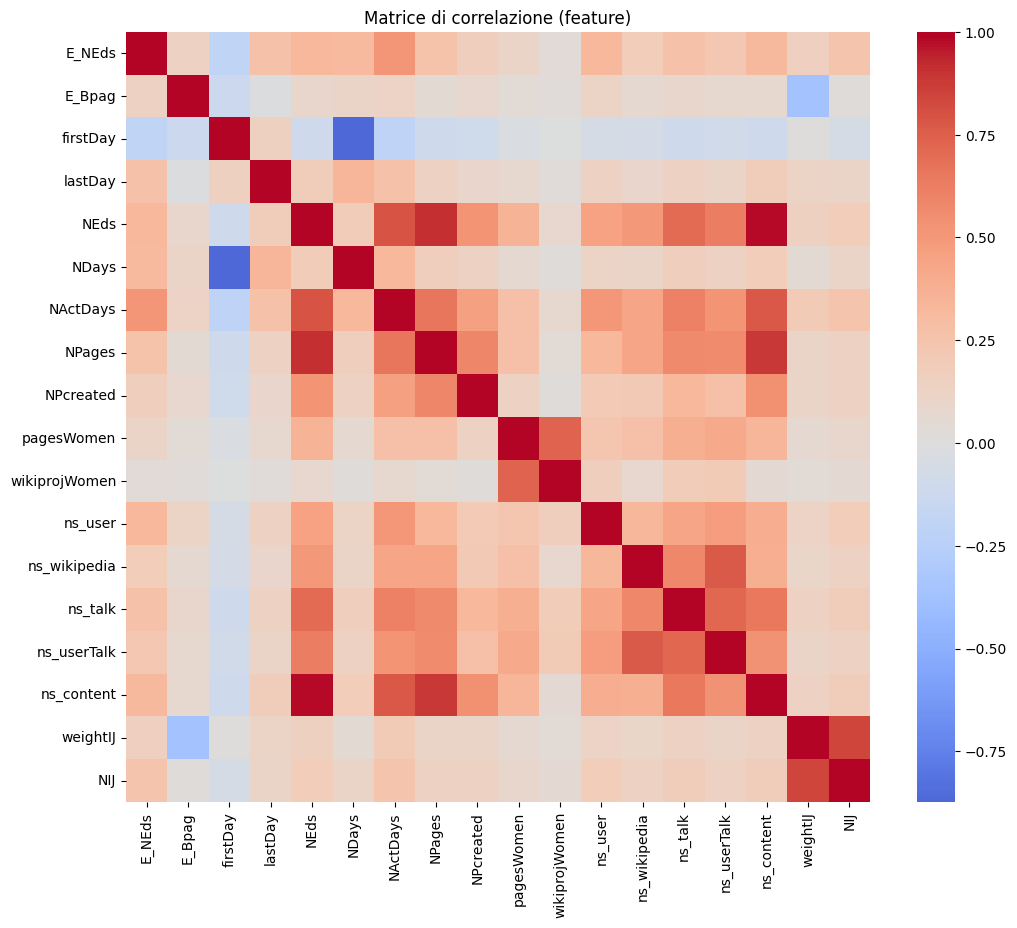

In [136]:
corr = df2_known.drop(columns=['gender']).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione (feature)")
plt.show()

##scatterplot e boxplot di relazioni specifiche

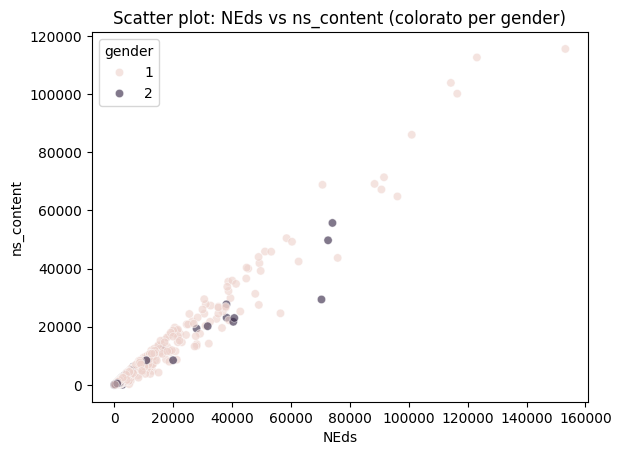

In [137]:
sns.scatterplot(
    x='NEds',
    y='ns_content',
    hue='gender',
    data=df2_known,
    alpha=0.6
)
plt.title("Scatter plot: NEds vs ns_content (colorato per gender)")
plt.show()

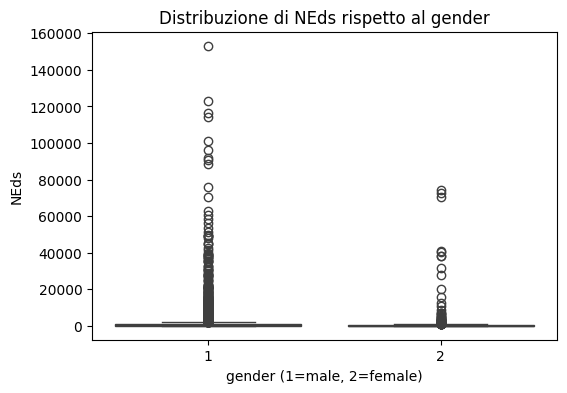

In [138]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='NEds', data=df2_known)
plt.title("Distribuzione di NEds rispetto al gender")
plt.xlabel("gender (1=male, 2=female)")
plt.show()

#FEATURE ENGENEERING E SELEZIONE

##train_test_split

In [139]:
X = df2_known.drop(columns=['gender','lastDay','firstDay'])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit su train
X_test_s  = scaler.transform(X_test)        # transform su test


## baseline classifier: evidenziamo lo sbilanciamento e i limiti dell'accuracy

In [140]:
# Modello di riferimento (baseline): non utilizza le feature ma predice
# esclusivamente la classe più frequente. Qualsiasi modello utile dovrà
# superare queste prestazioni, soprattutto sulla classe minoritaria.

one_class_clf = DummyClassifier(strategy="most_frequent")
one_class_clf.fit(X_train_s, y_train)

y_pred_one_class = one_class_clf.predict(X_test_s)

print("One-Class Classifier (Baseline)")
print(classification_report(y_test,y_pred_one_class,zero_division=0))

cm = confusion_matrix(y_test, y_pred_one_class)
print(cm)


One-Class Classifier (Baseline)
              precision    recall  f1-score   support

           1       0.90      1.00      0.95       567
           2       0.00      0.00      0.00        62

    accuracy                           0.90       629
   macro avg       0.45      0.50      0.47       629
weighted avg       0.81      0.90      0.85       629

[[567   0]
 [ 62   0]]


#DEFINIZIONE E ADDESTRAMENTO DEI MODELLI SENZA SELEZIONE DI FEATURE

In [141]:
#Definiamo un dizionario con i modelli da testare
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gaussian Naive Bayes": GaussianNB()
}

# Dizionario per salvare i risultati
results_full = {}



========== Logistic Regression ==========
Sensitivity (Recall Female): 0.6613
Specificity (Recall Male):   0.6226
Precision (Female):          0.1608
F1-Score (Female):           0.2587
----------------------------------------
              precision    recall  f1-score   support

    Male (1)       0.94      0.62      0.75       567
  Female (2)       0.16      0.66      0.26        62

    accuracy                           0.63       629
   macro avg       0.55      0.64      0.50       629
weighted avg       0.87      0.63      0.70       629


========== Random Forest ==========
Sensitivity (Recall Female): 0.1774
Specificity (Recall Male):   0.9929
Precision (Female):          0.7333
F1-Score (Female):           0.2857
----------------------------------------
              precision    recall  f1-score   support

    Male (1)       0.92      0.99      0.95       567
  Female (2)       0.73      0.18      0.29        62

    accuracy                           0.91       629
   ma

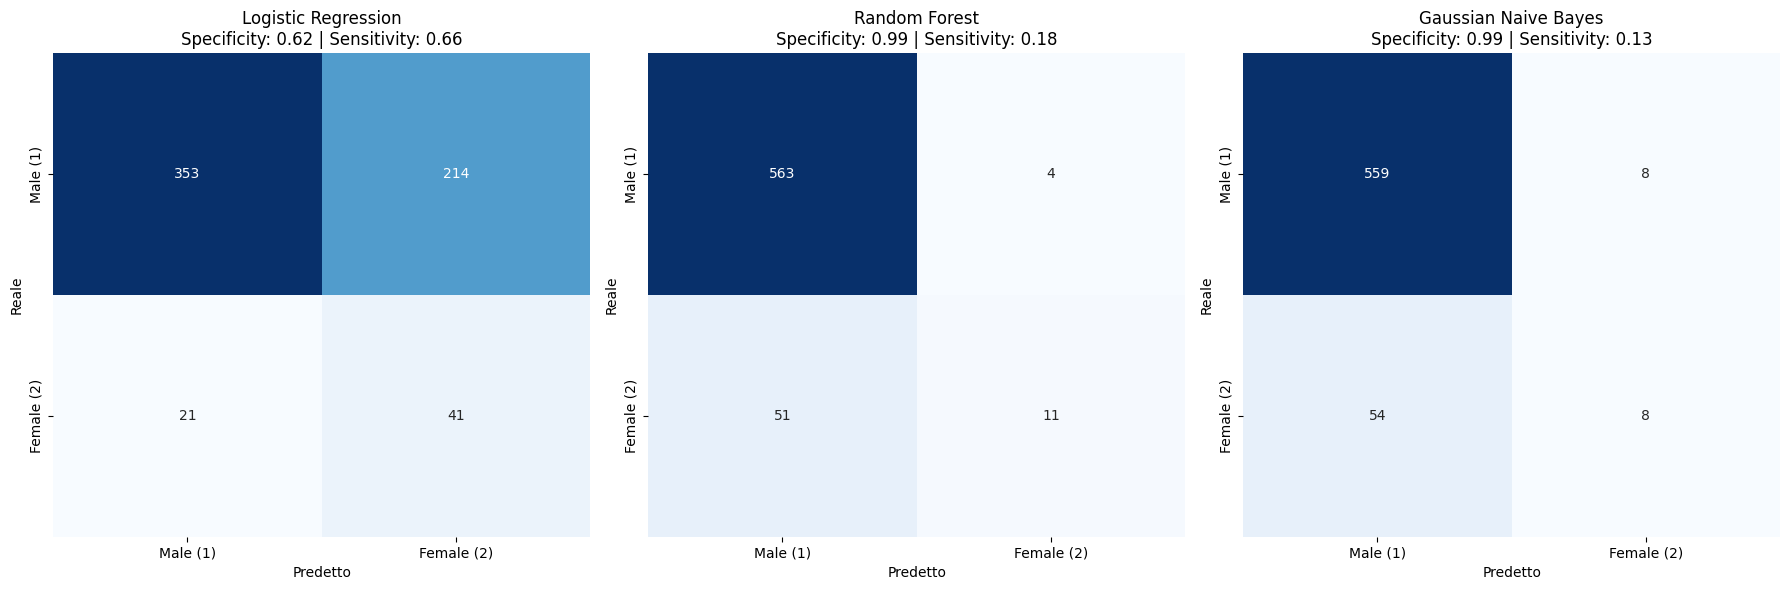

In [142]:
labels = [1, 2]          # 1=Male, 2=Female
pos = 2                  # classe positiva = Female

plt.figure(figsize=(18, 6))

for i, (name, model) in enumerate(models.items()):
    # Scegli input giusto per modello
    if name == "Random Forest":
        Xtr, Xte = X_train, X_test
    else:
        Xtr, Xte = X_train_s, X_test_s
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    # 2. Calcolo Metriche dal Summary
    # Calcoliamo la Matrice di Confusione per estrarre TN, FP, FN, TP
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()

    # Calcolo manuale della Specificity
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    #altre metriche prese con sklearn
    sensitivity = recall_score(y_test, y_pred, labels=labels, pos_label=2, zero_division=0)
    precision = precision_score(y_test, y_pred,labels=labels, pos_label=2, zero_division=0)
    f1 = f1_score(y_test, y_pred,labels=labels, pos_label=2, zero_division=0)

    # Salviamo le metriche per confrontare i modelli alla fine
    results_full[name] = {
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1
    }

    print(f"\n{'='*10} {name} {'='*10}")
    print(f"Sensitivity (Recall Female): {sensitivity:.4f}")
    print(f"Specificity (Recall Male):   {specificity:.4f}")
    print(f"Precision (Female):          {precision:.4f}")
    print(f"F1-Score (Female):           {f1:.4f}")
    print("-" * 40)


    print(classification_report(
        y_test, y_pred,
        labels=labels,
        target_names=['Male (1)', 'Female (2)'],
        zero_division=0
    ))

    # 4. Grafico Matrice di Confusione
    plt.subplot(1, len(models), i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Male (1)', 'Female (2)'],
                yticklabels=['Male (1)', 'Female (2)'])
    plt.title(f"{name}\nSpecificity: {specificity:.2f} | Sensitivity: {sensitivity:.2f}")
    plt.ylabel('Reale')
    plt.xlabel('Predetto')

plt.tight_layout()
plt.show()

##analisi importanza feature con Random Forest

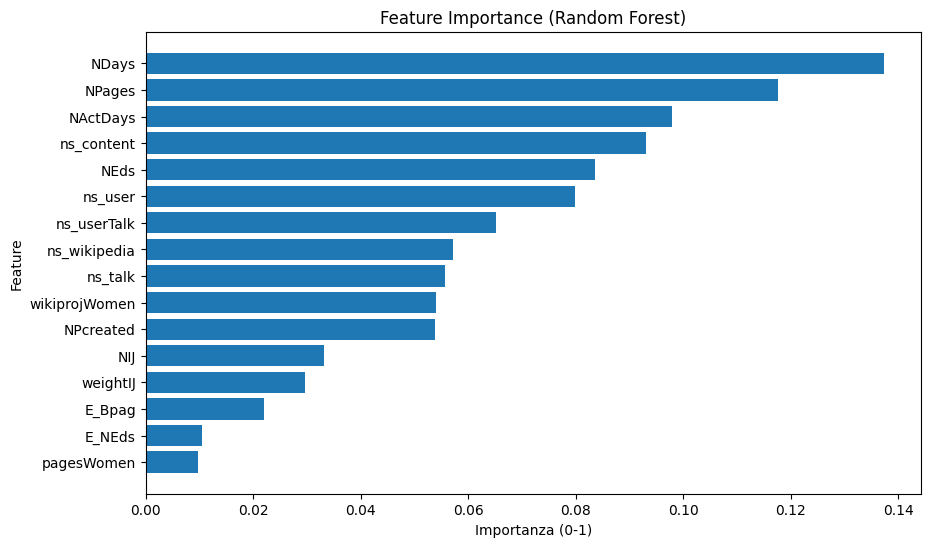

In [143]:
# 1. Inizializzazione del modello
# n_estimators=200 crea 200 alberi decisionali
# random_state=42 garantisce che il risultato sia riproducibile
rf = RandomForestClassifier(n_estimators=200, random_state=42)

# 2. Addestramento (Fit) SOLO sul Training Set
# Qui il modello impara le relazioni non lineari tra X_train e y_train
rf.fit(X_train, y_train)

# 3. Estrazione dell'importanza delle feature
# I valori sommano a 1. Più alto è il valore, più forte è la relazione.
importances = rf.feature_importances_

# 4. Creazione di un DataFrame per visualizzare i risultati
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualizzazione grafica
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
plt.xlabel('Importanza (0-1)')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis() # Inverte l'asse y per avere la feature più importante in alto
plt.show()

##matrice di correlazione tra le top 11 features

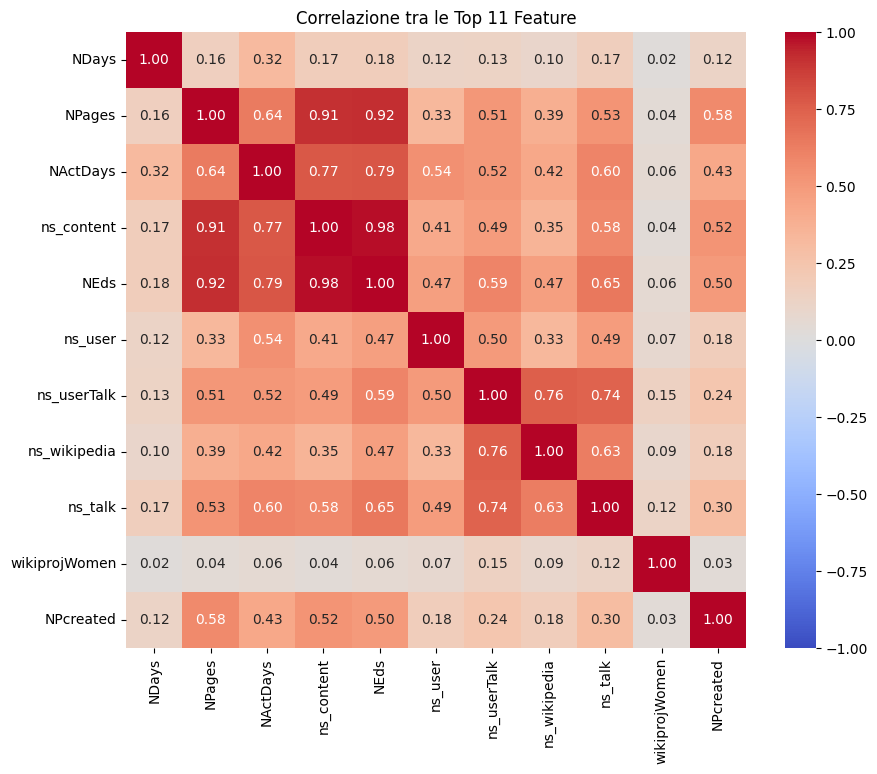

In [144]:
# Lista delle feature selezionate
top_k = 11
selected_features = feature_imp_df['Feature'].head(top_k).tolist()

# Calcolo della matrice di correlazione solo su queste
corr_matrix = X_train[selected_features].corr()

# Visualizzazione
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlazione tra le Top 11 Feature')
plt.show()

##rimozione feature non correlate o ridondanti

In [145]:
#Definizione della funzione di pulizia.
def remove_highly_correlated_features(X_train, importance_df, threshold=0.95):
    # Calcolo matrice correlazione
    corr_matrix = X_train.corr().abs() #abs perchè mi interessa la forza della relazione e non il segno
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    imp_map = dict(zip(importance_df['Feature'], importance_df['Importance']))
    to_drop = set() # per non aggiungere duplicati

    for column in upper.columns:
        # Trova feature correlate sopra la soglia
        correlated_features = upper.index[upper[column] > threshold].tolist()

        for feature in correlated_features:
            # Recupera importanza
            imp_col  = imp_map.get(column, 0)
            imp_feat = imp_map.get(feature, 0)


            # Decide chi eliminare
            if imp_col < imp_feat:
                print(f"Elimino '{column}' (conflitto con '{feature}')")
                to_drop.add(column)
            else:
                print(f"Elimino '{feature}' (conflitto con '{column}')")
                to_drop.add(feature)

    return list(to_drop)

# Selezione delle Top 11
top_k = 11
top_11_features = feature_imp_df['Feature'].head(top_k).tolist()

X_train_sub = X_train[top_11_features].copy()
X_test_sub = X_test[top_11_features].copy()

print(f"1. Shape iniziale (Top 11): {X_train_sub.shape}")

# Rimozione Automatica features ridondanti
features_to_drop = remove_highly_correlated_features(X_train_sub, feature_imp_df, threshold=0.95)

# Creiamo i dataset finali
X_train_final = X_train_sub.drop(columns=features_to_drop)
X_test_final = X_test_sub.drop(columns=features_to_drop)

print(f"2. Shape finale: {X_train_final.shape}")
print(f"Feature rimaste ({len(X_train_final.columns)}): {X_train_final.columns.tolist()}")

1. Shape iniziale (Top 11): (2516, 11)
Elimino 'NEds' (conflitto con 'ns_content')
2. Shape finale: (2516, 10)
Feature rimaste (10): ['NDays', 'NPages', 'NActDays', 'ns_content', 'ns_user', 'ns_userTalk', 'ns_wikipedia', 'ns_talk', 'wikiprojWomen', 'NPcreated']


In [146]:
X_train_final.reset_index(drop=True, inplace=True)
X_train_final.head()

,NDays,NPages,NActDays,ns_content,ns_user,ns_userTalk,ns_wikipedia,ns_talk,wikiprojWomen,NPcreated
0,1713,516,298,1141,1498,634,211,59,0,28
1,973,22,20,57,12,10,0,0,0,4
2,2948,218,84,555,4,1,13,7,0,72
3,2290,1306,1207,12593,234,79,59,59,0,36
4,2861,326,210,890,74,16,4,27,0,29


##scaling finale

In [147]:
# Inizializziamo lo scaler
scaler_final = StandardScaler()

# Facciamo il fit solo sul train, Transform su train e test
# Questo evita il Data Leakage
X_train_scaled = scaler_final.fit_transform(X_train_final)
X_test_scaled = scaler_final.transform(X_test_final)



#DEFINIZIONE E ADDESTRAMENTO DEI MODELLI SU FEATURE SELEZIONATE

In [148]:
# Definiamo un dizionario con i modelli da testare
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gaussian Naive Bayes": GaussianNB()
}

# Dizionario per salvare i risultati
results_selected = {}


========== Logistic Regression ==========
Sensitivity (Recall Female): 0.6774
Specificity (Recall Male):   0.6014
Precision (Female):          0.1567
F1-Score (Female):           0.2545
----------------------------------------
              precision    recall  f1-score   support

    Male (1)       0.94      0.60      0.73       567
  Female (2)       0.16      0.68      0.25        62

    accuracy                           0.61       629
   macro avg       0.55      0.64      0.49       629
weighted avg       0.87      0.61      0.69       629


========== Random Forest ==========
Sensitivity (Recall Female): 0.1452
Specificity (Recall Male):   0.9912
Precision (Female):          0.6429
F1-Score (Female):           0.2368
----------------------------------------
              precision    recall  f1-score   support

    Male (1)       0.91      0.99      0.95       567
  Female (2)       0.64      0.15      0.24        62

    accuracy                           0.91       629
   ma

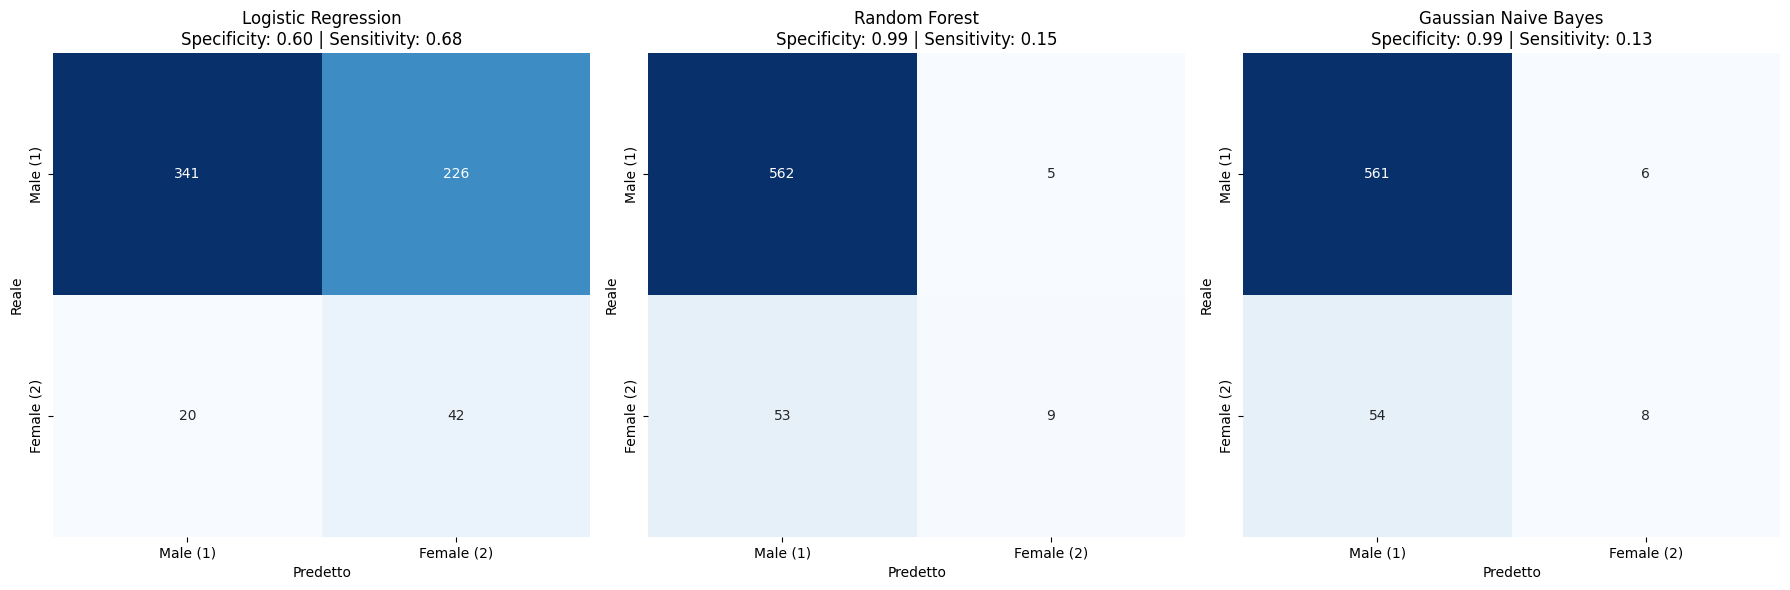

In [149]:
labels = [1, 2]
pos = 2

plt.figure(figsize=(18, 6))

for i, (name, model) in enumerate(models.items()):
    if name == "Random Forest":
        Xtr, Xte = X_train_final, X_test_final
    else:
        Xtr, Xte = X_train_scaled, X_test_scaled
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)


    # Calcoliamo la Matrice di Confusione per estrarre TN, FP, FN, TP
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()

    # Calcolo manuale della Specificity
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    # Le altre metriche le prendiamo da sklearn
    sensitivity = recall_score(y_test, y_pred, labels=labels, pos_label=2, zero_division=0) # 2 è la classe Female
    precision = precision_score(y_test, y_pred,labels=labels, pos_label=2, zero_division=0)
    f1 = f1_score(y_test, y_pred,labels=labels, pos_label=2, zero_division=0)

    # Salviamo le metriche per confrontare i modelli alla fine
    results_selected[name] = {
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1
    }

    print(f"\n{'='*10} {name} {'='*10}")
    print(f"Sensitivity (Recall Female): {sensitivity:.4f}")
    print(f"Specificity (Recall Male):   {specificity:.4f}")
    print(f"Precision (Female):          {precision:.4f}")
    print(f"F1-Score (Female):           {f1:.4f}")
    print("-" * 40)


    print(classification_report(
        y_test, y_pred,
        labels=labels,
        target_names=['Male (1)', 'Female (2)'],
        zero_division=0
    ))

    #Grafico Matrice di Confusione
    plt.subplot(1, len(models), i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Male (1)', 'Female (2)'],
                yticklabels=['Male (1)', 'Female (2)'])
    plt.title(f"{name}\nSpecificity: {specificity:.2f} | Sensitivity: {sensitivity:.2f}")
    plt.ylabel('Reale')
    plt.xlabel('Predetto')

plt.tight_layout()
plt.show()

Abbiamo utilizzato un modello lineare, la regressione logistica, per valutare se le feature presentassero una separabilità lineare rispetto al genere. Nonostante un buon recall sulla classe minoritaria, il basso valore di precision e F1-score indica una forte sovrapposizione tra le classi, suggerendo che le metriche di editing non sono sufficientemente informative per una distinzione affidabile.

#CONFRONTO CON MODELLO CON TUTTE LE FEATURE

In [150]:
metrics = ["Sensitivity", "Specificity", "Precision", "F1"]

print("\n=== CONFRONTO FULL vs SELECTED ===")
for metric in metrics:
    print(f"\n--- {metric} (Female) ---")
    for name in models.keys():
        val_full = results_full[name][metric]
        val_sel  = results_selected[name][metric]
        print(f"{name:<20} FULL: {val_full:.4f} | SELECTED: {val_sel:.4f}")





=== CONFRONTO FULL vs SELECTED ===

--- Sensitivity (Female) ---
Logistic Regression  FULL: 0.6613 | SELECTED: 0.6774
Random Forest        FULL: 0.1774 | SELECTED: 0.1452
Gaussian Naive Bayes FULL: 0.1290 | SELECTED: 0.1290

--- Specificity (Female) ---
Logistic Regression  FULL: 0.6226 | SELECTED: 0.6014
Random Forest        FULL: 0.9929 | SELECTED: 0.9912
Gaussian Naive Bayes FULL: 0.9859 | SELECTED: 0.9894

--- Precision (Female) ---
Logistic Regression  FULL: 0.1608 | SELECTED: 0.1567
Random Forest        FULL: 0.7333 | SELECTED: 0.6429
Gaussian Naive Bayes FULL: 0.5000 | SELECTED: 0.5714

--- F1 (Female) ---
Logistic Regression  FULL: 0.2587 | SELECTED: 0.2545
Random Forest        FULL: 0.2857 | SELECTED: 0.2368
Gaussian Naive Bayes FULL: 0.2051 | SELECTED: 0.2105


#MODEL SELECTION

In [151]:
# metrica: F1 sulla classe "female" = 2
f1_female = make_scorer(f1_score, pos_label=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=5000))
])

param_lr = {
    "clf__C": [0.01, 0.1, 1, 10, 50],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}

gs_lr = GridSearchCV(pipe_lr, param_lr, scoring=f1_female, cv=cv, n_jobs=-1)
gs_lr.fit(X_train_final, y_train)

print("BEST LR params:", gs_lr.best_params_)
print("BEST LR CV F1 female:", gs_lr.best_score_)



BEST LR params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
BEST LR CV F1 female: 0.30923632772058735


In [152]:
best_lr = gs_lr.best_estimator_
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

best_lr.fit(X_tr, y_tr)
# probabilità della classe 2
classes = best_lr.named_steps["clf"].classes_
idx_female = np.where(classes == 2)[0][0]
proba_val = best_lr.predict_proba(X_val)[:, idx_female]

thresholds = np.linspace(0.05, 0.95, 91)
f1s = []

for t in thresholds:
    y_pred_val = np.where(proba_val >= t, 2, 1)
    f1s.append(f1_score(y_val, y_pred_val, pos_label=2, zero_division=0))

best_t = thresholds[int(np.argmax(f1s))]
print("BEST threshold:", best_t, "F1 female:", max(f1s))

#3) Report FINALE sul TEST
proba_test = best_lr.predict_proba(X_test_final)[:, idx_female]
y_pred_test = np.where(proba_test >= best_t, 2, 1)

print("\n=== FINAL REPORT (LR + tuned threshold) ===")
print(confusion_matrix(y_test, y_pred_test, labels=[1,2]))
print(classification_report(
    y_test, y_pred_test,
    labels=[1,2],
    target_names=['Male (1)', 'Female (2)'],
    zero_division=0
))

BEST threshold: 0.6599999999999999 F1 female: 0.42276422764227645

=== FINAL REPORT (LR + tuned threshold) ===
[[504  63]
 [ 35  27]]
              precision    recall  f1-score   support

    Male (1)       0.94      0.89      0.91       567
  Female (2)       0.30      0.44      0.36        62

    accuracy                           0.84       629
   macro avg       0.62      0.66      0.63       629
weighted avg       0.87      0.84      0.86       629



La soglia di decisione ottimale non risulta stabile tra diverse esecuzioni del modello, oscillando intorno a valori compresi tra 0.60 e 0.65. Questa variabilità è dovuta sia allo sbilanciamento del dataset sia alla forte sovrapposizione tra le distribuzioni delle probabilità predette per le due classi. L’assenza di una threshold robusta conferma che le feature disponibili non consentono una separazione netta tra utenti maschili e femminili.

# PREVISIONE SUGLI UNKOWN

In [153]:
print(type(best_lr))
print(best_lr.classes_)


<class 'sklearn.pipeline.Pipeline'>
[1 2]


In [154]:
# Dati unknown con le stesse feature del training
X_unknown_df = df2_unknown[X_train_final.columns].copy()

# Probabilità direttamente dalla pipeline
proba = best_lr.predict_proba(X_unknown_df)

classes = best_lr.classes_
idx_male = list(classes).index(1)
idx_female = list(classes).index(2)

prob_male_mean = proba[:, idx_male].mean()
prob_female_mean = proba[:, idx_female].mean()

print(f"Maschi (stimati): {prob_male_mean*100:.2f}%")
print(f"Femmine (stimate): {prob_female_mean*100:.2f}%")


Maschi (stimati): 56.73%
Femmine (stimate): 43.27%
